<div style="background-color:#0D2741;background-image:linear-gradient(90deg,#0D2741,#1d4063);color:#ffffff;padding:24px 28px;border-radius:8px;">
<div style="font-size:12.5px;letter-spacing:1.5px;color:#aac4dd;">UNIVERSIDAD ANDRÉS BELLO · MAGÍSTER EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL</div>
<div style="font-size:27px;font-weight:700;margin-top:8px;line-height:1.15;">Introducción a la Simulación Monte Carlo</div>
<div style="font-size:17px;color:#d7e3ef;margin-top:2px;">Definición, origen y aplicaciones</div>
<div style="margin-top:12px;font-size:12.5px;color:#aac4dd;">Maidana, J.P. · 2026 · Apunte de cátedra</div>
</div>


In [1]:
import numpy as np
import scipy
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline

# Paleta institucional UNAB
UNAB_NAVY = "#0D2741"
UNAB_RED  = "#AE0000"
VERDE     = "#2E8B57"
NARANJA   = "#E08600"
MORADO    = "#7E57C2"

mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

print(f"numpy {np.__version__} · scipy {scipy.__version__} · matplotlib {mpl.__version__}")


numpy 2.4.4 · scipy 1.17.1 · matplotlib 3.10.8


## 1. Introducción: el poder de la simulación

Consideremos un problema complejo que enfrentan las compañías de seguros: necesitan calcular la probabilidad de que sus reservas alcancen para cubrir todas las reclamaciones del próximo año. El problema involucra miles de pólizas con coberturas distintas, probabilidades variables de reclamación según el perfil del cliente, montos aleatorios, correlaciones entre eventos (un desastre natural afecta a muchos a la vez) e incertidumbre económica sobre las inversiones.

¿Cómo se resuelve esto de forma analítica? Las ecuaciones serían extremadamente complejas, si es que existe una solución cerrada. Aquí entra el **método Monte Carlo**.

En lugar de resolver el problema con matemática pura, Monte Carlo propone otra cosa: *simular* el sistema muchas veces usando aleatoriedad y observar qué ocurre. Es como realizar miles de experimentos virtuales para ver el rango de resultados posibles.

> *"Si un problema es demasiado complejo para resolverlo analíticamente, podemos aproximar la respuesta mediante simulación estocástica."*

Este enfoque ha transformado campos tan diversos como la física nuclear, las finanzas, la inteligencia artificial, la logística, la medicina y la epidemiología. El esquema siguiente resume la idea central.


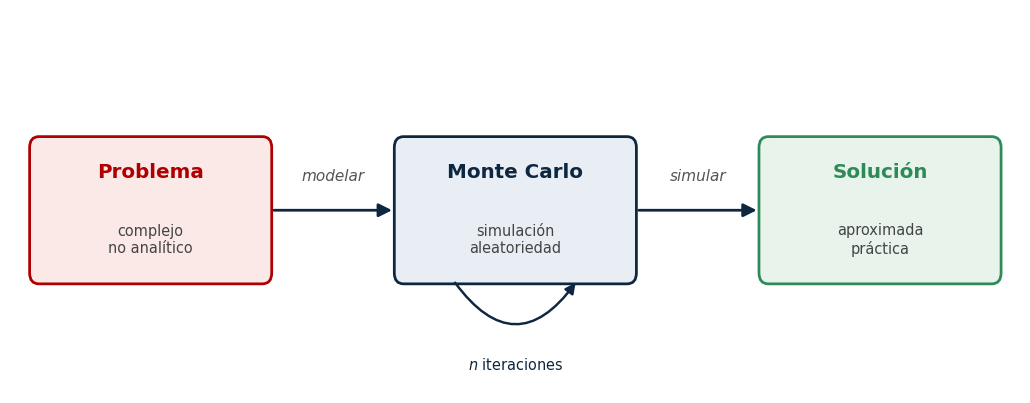

In [2]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(9.5, 3.8))
ax.set_xlim(0, 13)
ax.set_ylim(-2.0, 2.2)
ax.axis("off")

cajas = [
    ("Problema",    "complejo\nno analítico",   "#fbe9e7", UNAB_RED),
    ("Monte Carlo", "simulación\naleatoriedad", "#e9eef5", UNAB_NAVY),
    ("Solución",    "aproximada\npráctica",     "#e8f3ec", VERDE),
]
xs = [1.8, 6.5, 11.2]
bw, bh = 3.0, 1.5
for (tit, sub, bg, bd), x in zip(cajas, xs):
    ax.add_patch(FancyBboxPatch((x-bw/2, -bh/2), bw, bh,
                 boxstyle="round,pad=0.06,rounding_size=0.12",
                 lw=1.8, edgecolor=bd, facecolor=bg))
    ax.text(x, 0.42, tit, ha="center", va="center", fontsize=13, fontweight="bold", color=bd)
    ax.text(x, -0.32, sub, ha="center", va="center", fontsize=9.5, color="#444444")

for x0, x1, lbl in [(xs[0], xs[1], "modelar"), (xs[1], xs[2], "simular")]:
    ax.add_patch(FancyArrowPatch((x0+bw/2+0.05, 0), (x1-bw/2-0.05, 0),
                 arrowstyle="-|>", mutation_scale=18, lw=1.8, color=UNAB_NAVY))
    ax.text((x0+x1)/2, 0.30, lbl, ha="center", va="bottom",
            fontsize=10, style="italic", color="#555555")

# Bucle "n iteraciones" por debajo de Monte Carlo
ax.add_patch(FancyArrowPatch((xs[1]-0.8, -bh/2-0.02), (xs[1]+0.8, -bh/2-0.02),
             connectionstyle="arc3,rad=0.7", arrowstyle="-|>",
             mutation_scale=14, lw=1.6, color=UNAB_NAVY))
ax.text(xs[1], -1.7, r"$n$ iteraciones", ha="center", va="center",
        fontsize=9.5, color=UNAB_NAVY)

plt.tight_layout()
plt.show()


<div style="background:#fbf8e8;border-left:5px solid #C9A400;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#7d6500;">Lo que aprenderás</strong>
<ol style="margin:8px 0 0 0;">
<li>Qué es el método Monte Carlo y cuándo es útil.</li>
<li>Su origen histórico y por qué se llama así.</li>
<li>La estructura general del algoritmo Monte Carlo.</li>
<li>Los tipos de problemas que resuelve.</li>
<li>Sus ventajas y limitaciones.</li>
<li>Cómo implementar simulaciones básicas en Python.</li>
<li>Aplicaciones en distintas industrias.</li>
<li>Consideraciones prácticas y buenas prácticas.</li>
</ol>
</div>


## 2. Definición y concepto

### 2.1 ¿Qué es el método Monte Carlo?

<div style="background:#eef3fb;border-left:5px solid #2563AE;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#1b4f87;">Método Monte Carlo</strong><br><br>
El <strong>método Monte Carlo</strong> es una clase de algoritmos que usan muestreo aleatorio repetido para obtener resultados numéricos. En vez de resolver el problema de forma determinística, genera numerosos escenarios aleatorios y usa sus resultados para aproximar la solución.<br><br>
<strong>Componentes esenciales:</strong>
<ol style="margin:6px 0 0 0;">
<li><strong>Dominio de entradas:</strong> variables que pueden tomar valores aleatorios.</li>
<li><strong>Generador de números aleatorios:</strong> produce muestras de las distribuciones especificadas.</li>
<li><strong>Modelo determinístico:</strong> reglas que transforman entradas en salidas.</li>
<li><strong>Agregación de resultados:</strong> estadísticos sobre las múltiples simulaciones.</li>
</ol><br>
<strong>Principio fundamental:</strong> la Ley de los Grandes Números garantiza que el promedio de muchas simulaciones converge a la esperanza verdadera.
</div>


**Analogía simple.** Imagina que quieres estimar cuánto tardas en llegar al trabajo en auto. En lugar de resolver ecuaciones de tráfico complejas, podrías: (1) generar 1,000 escenarios aleatorios de tráfico (pesado, moderado, ligero); (2) para cada uno, simular el viaje considerando semáforos, accidentes y clima; (3) promediar los 1,000 tiempos. Ese promedio es tu estimación Monte Carlo del tiempo esperado de viaje.

### 2.2 Características clave

El método es **estocástico** (usa aleatoriedad como herramienta central), **repetitivo** (necesita muchas iteraciones para converger), **computacional** (depende del cómputo), **aproximado** (entrega estimaciones, no soluciones exactas), **flexible** (aplicable a problemas muy diversos) y **escalable** (más simulaciones, más precisión).

<div style="background:#fdf4e7;border-left:5px solid #E08600;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#9a5b00;">¿Cuándo usar Monte Carlo?</strong>
<p style="margin:6px 0 0 0;">Es especialmente útil cuando:</p>
<ol style="margin:4px 0 0 0;">
<li>El problema es <strong>estocástico</strong> por naturaleza.</li>
<li>No hay <strong>solución analítica</strong> cerrada, o es muy compleja.</li>
<li>Hay <strong>múltiples fuentes de incertidumbre</strong>.</li>
<li>Se necesita explorar un <strong>espacio grande</strong> de posibilidades.</li>
<li>El modelo es <strong>no lineal</strong> o tiene interacciones complejas.</li>
<li>Se requiere estimar <strong>probabilidades de eventos raros</strong>.</li>
<li>El cálculo directo es <strong>computacionalmente prohibitivo</strong>.</li>
</ol>
<p style="margin-top:8px;"><strong>Criterio general:</strong> si puedes simular el proceso una vez, puedes usar Monte Carlo para entender su comportamiento promedio.</p>
</div>


## 3. Origen e historia

### 3.1 El nombre: los casinos de Montecarlo

<div style="background:#f3eefb;border-left:5px solid #7E57C2;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#5331a0;">¿Por qué "Monte Carlo"?</strong><br><br>
El nombre viene del famoso distrito de Montecarlo, en Mónaco, conocido por sus casinos. El método fue bautizado así en la década de 1940 por científicos del Proyecto Manhattan (desarrollo de armas nucleares durante la Segunda Guerra Mundial).<br><br>
<strong>El contexto:</strong>
<ul style="margin:6px 0 0 0;">
<li><strong>Stanisław Ulam</strong>, matemático polaco-estadounidense, estaba convaleciente de una enfermedad.</li>
<li>Jugaba solitarios y se preguntó por sus probabilidades de éxito.</li>
<li>Se dio cuenta de que era más fácil estimar esas probabilidades mediante experimentos que mediante cálculo analítico.</li>
<li>Su tío frecuentaba los casinos de Montecarlo: de ahí la inspiración del nombre.</li>
</ul><br>
<strong>Colaboradores clave:</strong>
<ul style="margin:6px 0 0 0;">
<li><strong>John von Neumann:</strong> reconoció el potencial y desarrolló algoritmos eficientes.</li>
<li><strong>Nicholas Metropolis:</strong> implementó los primeros códigos computacionales.</li>
<li><strong>Enrico Fermi:</strong> ya había usado técnicas similares en los años 30.</li>
</ul><br>
El método se mantuvo clasificado hasta 1949 por su uso en investigación nuclear militar.
</div>


### 3.2 Aplicación original: difusión de neutrones

El problema que motivó el desarrollo formal del método fue la **difusión de neutrones** en materiales fisionables. Los neutrones viajan, chocan con núcleos y pueden ser absorbidos o reflejados; sus trayectorias son aleatorias y muy complejas. Se necesitaba conocer qué fracción de neutrones provoca fisiones en cadena, pero las ecuaciones de transporte eran intratables de forma analítica.

La **solución Monte Carlo**: en vez de resolver las ecuaciones, se simuló la trayectoria de miles de neutrones individuales, cada uno con comportamiento aleatorio basado en probabilidades físicas conocidas. Al agregar los resultados de muchas trayectorias se obtuvieron estimaciones precisas de las cantidades de interés.

### 3.3 Evolución histórica

| Época | Desarrollo |
|:--|:--|
| Antes de 1940 | Ya existían métodos estadísticos de muestreo, pero de forma *ad hoc*. |
| 1940s | Formalización durante el Proyecto Manhattan; primeras implementaciones computacionales. |
| 1950s–60s | Expansión a física, química e investigación de operaciones. |
| 1970s–80s | Aplicaciones en finanzas (pricing de opciones) y estadística bayesiana. |
| 1990s | Los métodos MCMC (*Markov Chain Monte Carlo*) se vuelven estándar en estadística. |
| 2000s–hoy | Machine learning, deep learning, big data; simulaciones masivas en GPU. |

**Factores que permitieron su expansión:** el aumento exponencial del poder de cómputo (Ley de Moore), mejores generadores de números pseudoaleatorios, algoritmos más eficientes (reducción de varianza, muestreo por importancia), la paralelización (GPU, clústers) y el software accesible (NumPy, SciPy, PyMC, etc.).


## 4. El algoritmo general

### 4.1 Estructura básica

<div style="background:#eef3fb;border-left:5px solid #2563AE;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#1b4f87;">Algoritmo Monte Carlo general</strong>
<ol style="margin:6px 0 0 0;">
<li><strong>Definir el dominio de entradas:</strong> identificar las variables aleatorias y especificar sus distribuciones.</li>
<li><strong>Generar entradas aleatorias:</strong> muestrear valores de cada distribución con un generador pseudoaleatorio.</li>
<li><strong>Ejecutar la simulación determinística:</strong> aplicar el modelo a las entradas y obtener el resultado de la iteración.</li>
<li><strong>Almacenar el resultado</strong> de esta simulación.</li>
<li><strong>Repetir los pasos 2–4</strong> un total de $N$ veces (típicamente $N = 10^4$ a $10^6$ o más).</li>
<li><strong>Agregar y analizar:</strong> calcular estadísticos (media, percentiles, probabilidades), visualizar la distribución y estimar la incertidumbre.</li>
</ol>
</div>


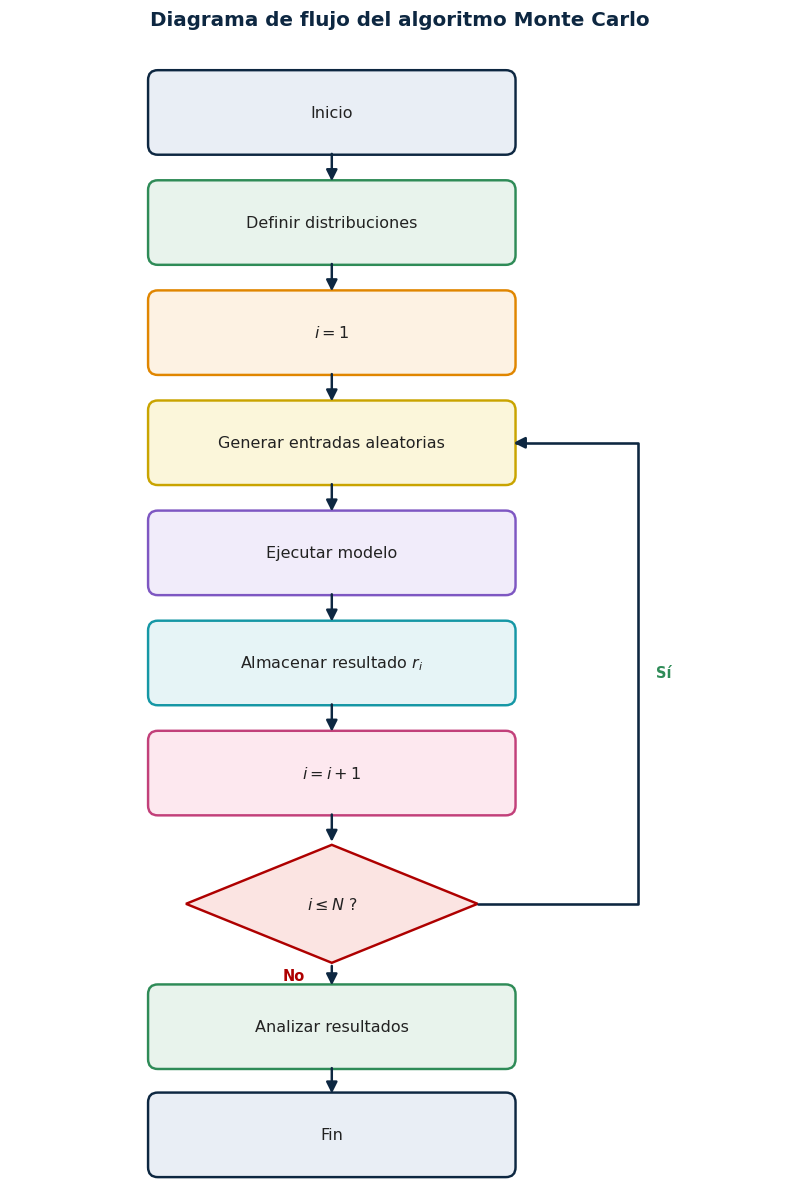

In [3]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Polygon
from matplotlib.path import Path

fig, ax = plt.subplots(figsize=(7.4, 11.0))
ax.set_xlim(0, 8)
ax.set_ylim(-0.3, 11.3)
ax.axis("off")

xc = 3.3
bw, bh = 3.7, 0.78
dia_w, dia_h = 1.5, 0.60

pasos = [
    ("Inicio",                      "#e9eef5", UNAB_NAVY),
    ("Definir distribuciones",      "#e8f3ec", VERDE),
    (r"$i = 1$",                    "#fdf2e3", NARANJA),
    ("Generar entradas aleatorias", "#fbf6da", "#C9A400"),
    ("Ejecutar modelo",             "#f1ecfa", MORADO),
    (r"Almacenar resultado $r_i$",  "#e6f4f6", "#1597a5"),
    (r"$i = i + 1$",                "#fde8ef", "#c2407a"),
]
ys = [10.6, 9.48, 8.36, 7.24, 6.12, 5.00, 3.88]
y_dia, y_an, y_fin = 2.55, 1.30, 0.20

def caja(y, txt, bg, bd):
    ax.add_patch(FancyBboxPatch((xc-bw/2, y-bh/2), bw, bh,
                 boxstyle="round,pad=0.04,rounding_size=0.10",
                 lw=1.6, edgecolor=bd, facecolor=bg))
    ax.text(xc, y, txt, ha="center", va="center", fontsize=10.5, color="#222222")

for (txt, bg, bd), y in zip(pasos, ys):
    caja(y, txt, bg, bd)

# Rombo de decisión
ax.add_patch(Polygon([(xc, y_dia+dia_h), (xc+dia_w, y_dia),
                      (xc, y_dia-dia_h), (xc-dia_w, y_dia)],
             closed=True, facecolor="#fbe4e2", edgecolor=UNAB_RED, lw=1.6))
ax.text(xc, y_dia, r"$i \leq N$ ?", ha="center", va="center", fontsize=10.5, color="#222222")

caja(y_an,  "Analizar resultados", "#e8f3ec", VERDE)
caja(y_fin, "Fin",                 "#e9eef5", UNAB_NAVY)

def flecha(y0, y1):
    ax.add_patch(FancyArrowPatch((xc, y0), (xc, y1),
                 arrowstyle="-|>", mutation_scale=15, lw=1.6, color=UNAB_NAVY))

for a, b in zip(ys[:-1], ys[1:]):     # secuencia 1 -> ... -> 7
    flecha(a-bh/2, b+bh/2)
flecha(ys[-1]-bh/2, y_dia+dia_h)      # 7 -> rombo
flecha(y_dia-dia_h, y_an+bh/2)        # rombo -> analizar  (No)
ax.text(xc-0.28, (y_dia-dia_h + y_an+bh/2)/2, "No", ha="right", va="center",
        fontsize=9.5, color=UNAB_RED, fontweight="bold")
flecha(y_an-bh/2, y_fin+bh/2)         # analizar -> fin

# Bucle "Sí": rombo (derecha) -> arriba -> entra a "Generar entradas"
x_r = xc + bw/2 + 1.3
y4  = ys[3]
loop = Path([(xc+dia_w, y_dia), (x_r, y_dia), (x_r, y4), (xc+bw/2+0.02, y4)])
ax.add_patch(FancyArrowPatch(path=loop, arrowstyle="-|>",
             mutation_scale=15, lw=1.7, color=UNAB_NAVY))
ax.text(x_r+0.18, (y_dia+y4)/2, "Sí", ha="left", va="center",
        fontsize=9.5, color=VERDE, fontweight="bold")

ax.set_title("Diagrama de flujo del algoritmo Monte Carlo", pad=12,
             fontsize=13, fontweight="bold", color=UNAB_NAVY)
plt.tight_layout()
plt.show()


### 4.2 Pseudocódigo

La siguiente plantilla captura la estructura general: recibe una función que genera entradas y otra que ejecuta el modelo, y devuelve el arreglo de resultados.

In [4]:
def simulacion_monte_carlo(n_simulaciones, generar_entradas, ejecutar_modelo):
    """
    Plantilla general para simulación Monte Carlo.

    Parameters
    ----------
    n_simulaciones   : int      - número de iteraciones
    generar_entradas : callable - genera entradas aleatorias
    ejecutar_modelo  : callable - ejecuta el modelo con las entradas

    Returns
    -------
    resultados : ndarray - resultados de todas las simulaciones
    """
    resultados = np.zeros(n_simulaciones)
    for i in range(n_simulaciones):
        entradas      = generar_entradas()
        resultados[i] = ejecutar_modelo(entradas)
    return resultados


def analizar_resultados(resultados):
    """Calcular estadísticos descriptivos."""
    return {
        "media":        np.mean(resultados),
        "mediana":      np.median(resultados),
        "desv_est":     np.std(resultados),
        "percentil_5":  np.percentile(resultados,  5),
        "percentil_95": np.percentile(resultados, 95),
        "min":          np.min(resultados),
        "max":          np.max(resultados),
    }


El ejemplo más clásico de Monte Carlo es **estimar $\pi$**: lanzamos puntos al azar en el cuadrado $[-1,1]^2$ y medimos la fracción que cae dentro del círculo unitario; esa fracción, multiplicada por 4, aproxima $\pi$. Lo usamos para verificar que la plantilla funciona.

In [5]:
# Demostración del template: estimación de pi por Monte Carlo
rng_demo = np.random.default_rng(0)

def generar_punto():
    return rng_demo.uniform(-1, 1, size=2)

def dentro_del_circulo(p):
    x, y = p
    return 4.0 if x*x + y*y <= 1.0 else 0.0

estimaciones = simulacion_monte_carlo(50_000, generar_punto, dentro_del_circulo)
res = analizar_resultados(estimaciones)
print(f"Estimación de pi: {res['media']:.4f}   (valor real: {np.pi:.4f})")


Estimación de pi: 3.1495   (valor real: 3.1416)


### 4.3 Ejemplo ilustrativo: beneficio mensual de una tienda online

<div style="background:#eef7f0;border-left:5px solid #2E8B57;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#20663f;">Modelo</strong>
$$\begin{aligned}
\text{Beneficio} &= \text{Ingresos} - \text{Costos}\\
\text{Ingresos}  &= \text{Visitantes}\times \text{Tasa de conversión}\times \text{Ticket promedio}\\
\text{Costos}    &= \text{Costos fijos} + 0.40\times \text{Ingresos}
\end{aligned}$$
<strong>Variables aleatorias:</strong>
<ul style="margin:6px 0 0 0;">
<li>Visitantes mensuales: $\sim N(10000,\ 1500)$</li>
<li>Tasa de conversión: $\sim N(0.025,\ 0.005)$</li>
<li>Ticket promedio: $\sim N(80,\ 15)$</li>
<li>Costos fijos: \$5,000 (determinístico)</li>
</ul>
</div>


In [6]:
def simular_beneficio_tienda(n_simulaciones=10_000, random_state=42):
    rng = np.random.default_rng(random_state)
    beneficios = np.zeros(n_simulaciones)

    for i in range(n_simulaciones):
        visitantes      = max(0, rng.normal(10_000, 1_500))
        tasa_conversion = np.clip(rng.normal(0.025, 0.005), 0, 1)
        ticket_promedio = max(0, rng.normal(80, 15))

        ingresos       = visitantes * tasa_conversion * ticket_promedio
        costos_totales = 5_000 + 0.40 * ingresos
        beneficios[i]  = ingresos - costos_totales

    return beneficios

beneficios = simular_beneficio_tienda()

print(f"Beneficio esperado:           ${beneficios.mean():,.2f}")
print(f"Desviación estándar:          ${beneficios.std():,.2f}")
print(f"Percentil 5%:                 ${np.percentile(beneficios, 5):,.2f}")
print(f"Percentil 95%:                ${np.percentile(beneficios, 95):,.2f}")
print(f"Probabilidad de pérdida:      {(beneficios < 0).mean()*100:.2f}%")
print(f"Prob. beneficio > $10,000:    {(beneficios > 10_000).mean()*100:.2f}%")


Beneficio esperado:           $7,062.80
Desviación estándar:          $3,878.09
Percentil 5%:                 $1,411.97
Percentil 95%:                $14,137.02
Probabilidad de pérdida:      1.31%
Prob. beneficio > $10,000:    20.86%


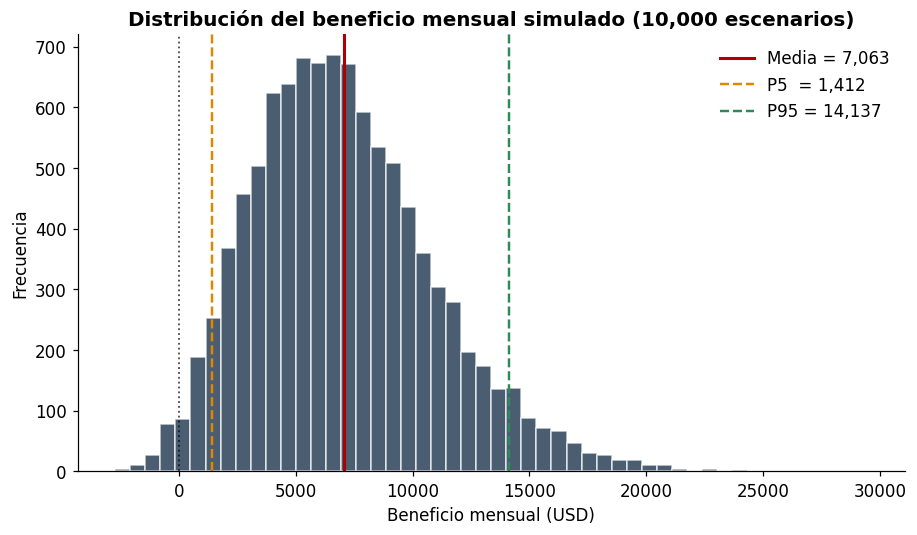

In [7]:
# Distribución completa de resultados (lo que Monte Carlo aporta sobre un único número)
p5, p95 = np.percentile(beneficios, [5, 95])
media   = beneficios.mean()

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(beneficios, bins=50, color=UNAB_NAVY, alpha=0.75, edgecolor="white")
ax.axvline(media, color=UNAB_RED, lw=2,   label=f"Media = {media:,.0f}")
ax.axvline(p5,    color=NARANJA, lw=1.6, ls="--", label=f"P5  = {p5:,.0f}")
ax.axvline(p95,   color=VERDE,   lw=1.6, ls="--", label=f"P95 = {p95:,.0f}")
ax.axvline(0,     color="black", lw=1.2, ls=":", alpha=0.7)
ax.set_xlabel("Beneficio mensual (USD)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución del beneficio mensual simulado (10,000 escenarios)")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretación.** Monte Carlo convierte un problema con varias fuentes de incertidumbre en una **distribución** de resultados posibles. En vez de un único número, obtenemos la distribución completa de beneficios, las probabilidades de escenarios concretos (pérdida, beneficio alto), una cuantificación del riesgo (percentiles, desviación estándar) y una visualización de la variabilidad.

## 5. Tipos de problemas y aplicaciones

El método es muy versátil. Sus aplicaciones pueden agruparse en cinco grandes categorías.

### 1. Optimización y búsqueda
Encontrar la mejor configuración de un sistema complejo: diseño óptimo de estructuras bajo incertidumbre, optimización de hiperparámetros por búsqueda aleatoria, rutas de distribución logística, programación de producción con demanda estocástica. La idea: generar muchas configuraciones aleatorias, evaluar cada una y quedarse con la mejor.

### 2. Análisis de riesgo
Cuantificar incertidumbre y evaluar riesgos: *Value at Risk* (VaR) y pricing de derivados en finanzas, reservas y pricing de pólizas en seguros, cronogramas (PERT/CPM estocástico) y evaluación de portafolios. Se modelan todas las fuentes de incertidumbre y se propagan por el sistema.

### 3. Física y ciencias naturales
Simular fenómenos físicos complejos (colisiones de partículas, dinámica molecular, modelos climáticos, propagación de enfermedades): se simula el comportamiento microscópico para entender propiedades macroscópicas.

### 4. Sistemas de colas y operaciones
Analizar sistemas con llegadas y servicios aleatorios (dimensionamiento de call centers, gestión de camas hospitalarias, intersecciones de tráfico, líneas de producción): se generan eventos aleatorios y se simula la operación.

### 5. Machine learning
Entrenamiento, inferencia y validación: *dropout* para regularización, *bootstrap* para estimar incertidumbre, MCMC para distribuciones posteriores en inferencia bayesiana, y modelos generativos (GAN, VAE).

| Industria | Aplicación | Pregunta |
|:--|:--|:--|
| Finanzas | Pricing de opciones | ¿Cuál es el valor justo de esta opción? |
| Seguros | Reservas | ¿Cuánto capital necesito para cubrir reclamaciones? |
| Farmacéutica | Ensayos clínicos | ¿Cuál es la probabilidad de éxito de la Fase III? |
| Energía | Gestión de portafolio | ¿Cómo optimizar el mix de generación con renovables? |
| Retail | Inventario | ¿Cuánto stock mantener con demanda incierta? |
| Manufactura | Capacidad | ¿Necesitamos expandir la planta? |
| Telecom | Red | ¿Cuánta capacidad para 99.9% de uptime? |


## 6. Ventajas y limitaciones

### 6.1 Ventajas

1. **Flexibilidad:** aplicable a problemas muy diversos sin exigir formas funcionales específicas.
2. **Intuitividad:** el concepto es fácil de entender y explicar a audiencias no técnicas.
3. **Escalabilidad:** más simulaciones implican mayor precisión, de forma controlada.
4. **Paralelización:** las simulaciones son independientes y fáciles de correr en paralelo.
5. **Distribución completa:** no solo el valor esperado, sino toda la distribución de resultados.
6. **Modelos complejos:** funciona con modelos no lineales, no convexos y discontinuos.
7. **Múltiples salidas:** se pueden analizar varias métricas a la vez.
8. **Análisis de sensibilidad:** es fácil variar inputs y observar el impacto.

### 6.2 Limitaciones y desafíos

<div style="background:#fbeeec;border-left:5px solid #C0392B;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#8e2a20;">Limitaciones del método Monte Carlo</strong>
<ol style="margin:6px 0 0 0;">
<li><strong>Costo computacional:</strong> requiere muchas evaluaciones del modelo.</li>
<li><strong>Convergencia lenta:</strong> el error es $\propto 1/\sqrt{N}$; reducirlo a la mitad exige $4\times$ más simulaciones.</li>
<li><strong>Calidad del modelo:</strong> si el modelo es incorrecto, los resultados también (<em>garbage in, garbage out</em>).</li>
<li><strong>Distribuciones de entrada:</strong> hay que especificar distribuciones correctas; los errores se propagan.</li>
<li><strong>Eventos raros:</strong> estimar probabilidades muy pequeñas ($10^{-6}$) exige simulaciones enormes.</li>
<li><strong>Alta dimensionalidad:</strong> en espacios de muchas dimensiones se necesitan exponencialmente más muestras.</li>
<li><strong>Dependencias:</strong> capturar bien las correlaciones entre variables puede ser difícil.</li>
<li><strong>Validación:</strong> es difícil verificar si una simulación es "correcta".</li>
</ol>
</div>

### 6.3 Cuándo NO usar Monte Carlo

Monte Carlo no siempre es la mejor herramienta. Conviene evitarlo cuando existe una solución analítica exacta (suele ser más rápida y precisa), cuando el problema es determinístico y simple, cuando no hay aleatoriedad real, cuando cada evaluación del modelo es muy costosa, o cuando los eventos de interés son extremadamente raros (ahí se usan técnicas especializadas como *importance sampling*).


## 7. Consideraciones prácticas

### 7.1 ¿Cuántas simulaciones?

**Reglas generales:** para exploración inicial, 1,000–10,000 simulaciones; para análisis estándar, 10,000–100,000; para alta precisión, 100,000–1,000,000+. El número necesario para eventos raros depende de la probabilidad del evento.

In [8]:
def estimar_error_montecarlo(resultados):
    """
    Error estándar de la media Monte Carlo:  SE = std / sqrt(n)
    """
    return np.std(resultados, ddof=1) / np.sqrt(len(resultados))


def calcular_n_necesario(std_estimado, error_deseado):
    """
    Número de simulaciones para alcanzar un SE objetivo:  n = (std / error)^2
    """
    return int(np.ceil((std_estimado / error_deseado) ** 2))


# Ejemplo
std_estimado  = 5_000   # de una simulación piloto
error_deseado = 100     # queremos SE < $100

n_necesario = calcular_n_necesario(std_estimado, error_deseado)
print(f"Simulaciones necesarias: {n_necesario:,}")
print(f"SE actual de los beneficios simulados: ${estimar_error_montecarlo(beneficios):,.2f}")


Simulaciones necesarias: 2,500
SE actual de los beneficios simulados: $38.78


### 7.2 Verificación de convergencia

La media acumulada debe estabilizarse a medida que crece $N$, y el error estándar debe decaer como $1/\sqrt{N}$. La función siguiente lo visualiza; la aplicamos a los beneficios simulados de la sección 4.3.

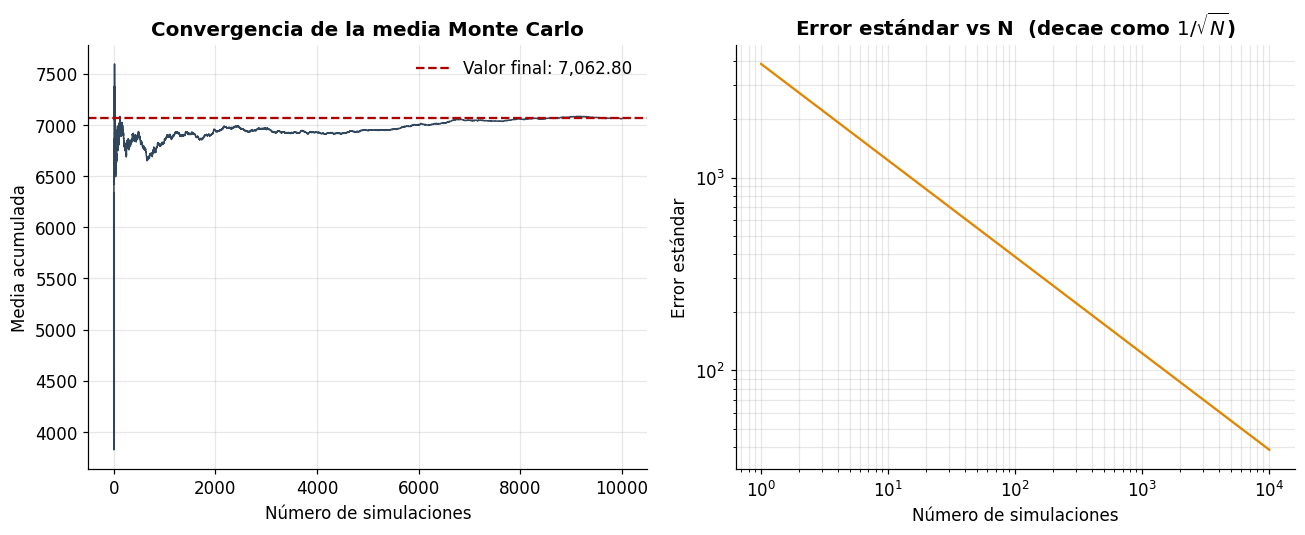

In [9]:
def graficar_convergencia(resultados):
    """Visualizar la convergencia de la media Monte Carlo."""
    n_vals  = np.arange(1, len(resultados) + 1)
    medias  = np.cumsum(resultados) / n_vals
    errores = np.std(resultados) / np.sqrt(n_vals)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(medias, lw=1, alpha=0.85, color=UNAB_NAVY)
    axes[0].axhline(medias[-1], color=UNAB_RED, ls="--",
                    label=f"Valor final: {medias[-1]:,.2f}")
    axes[0].set_xlabel("Número de simulaciones")
    axes[0].set_ylabel("Media acumulada")
    axes[0].set_title("Convergencia de la media Monte Carlo")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(n_vals, errores, lw=1.5, color=NARANJA)
    axes[1].set_xlabel("Número de simulaciones")
    axes[1].set_ylabel("Error estándar")
    axes[1].set_title("Error estándar vs N  (decae como $1/\\sqrt{N}$)")
    axes[1].set_xscale("log"); axes[1].set_yscale("log")
    axes[1].grid(alpha=0.3, which="both")

    plt.tight_layout()
    plt.show()

graficar_convergencia(beneficios)


### 7.3 Reproducibilidad

Usa siempre una semilla para garantizar resultados reproducibles. Sin semilla (`random_state=None`) cada corrida genera un flujo aleatorio distinto.

In [10]:
# Sin semilla (random_state=None) -> resultados NO reproducibles
r1 = simular_beneficio_tienda(1_000, random_state=None)
r2 = simular_beneficio_tienda(1_000, random_state=None)
print("Sin semilla, ¿iguales?:", np.allclose(r1, r2))   # False

# Con semilla fija -> resultados reproducibles
r1 = simular_beneficio_tienda(1_000, random_state=42)
r2 = simular_beneficio_tienda(1_000, random_state=42)
print("Con semilla,  ¿iguales?:", np.allclose(r1, r2))   # True


Sin semilla, ¿iguales?: False
Con semilla,  ¿iguales?: True


## 8. Resumen y puntos clave

1. El **método Monte Carlo** usa muestreo aleatorio repetido para aproximar soluciones a problemas complejos.
2. Nació en los años 1940, durante el Proyecto Manhattan, para resolver la difusión de neutrones.
3. Algoritmo general: (1) definir distribuciones, (2) generar entradas, (3) ejecutar el modelo, (4) repetir muchas veces, (5) analizar resultados.
4. Es útil cuando el problema es estocástico, no tiene solución analítica o involucra múltiples incertidumbres.
5. Aplicaciones en finanzas, seguros, física, ingeniería, machine learning, investigación de operaciones y muchos campos más.
6. Ventajas: flexible, intuitivo, paralelizable y entrega distribuciones completas de resultados.
7. Limitaciones: costo computacional, convergencia lenta $O(1/\sqrt{N})$, y dependencia de un buen modelado y de las distribuciones de entrada.
8. El número de simulaciones depende de la precisión deseada; para análisis estándar se usan 10,000–100,000 iteraciones.
9. Verifica siempre la convergencia y usa semillas para reproducibilidad.


<div style="background-color:#0D2741;background-image:linear-gradient(90deg,#0D2741,#1d4063);color:#eef2f7;padding:18px 22px;border-radius:8px;margin:14px 0;">
<strong style="color:#ffffff;font-size:15px;">Cierre</strong><br><br>
El método Monte Carlo transforma problemas complejos e intratables en simulaciones computacionales accesibles. Su poder está en combinar simplicidad conceptual con la capacidad de manejar complejidad arbitraria. En la era del big data y el cómputo abundante, se ha vuelto una herramienta indispensable para cuantificar incertidumbre y tomar decisiones informadas en entornos estocásticos. Dominarlo es, en el fondo, aprender a convertir la aleatoriedad en conocimiento.
</div>
